# Experiment 1 — Baseline Model (OLS / Linear Regression)

**Author:** Bryan  
**Data:** `train_updated.csv`, `test_updated.csv` (from  `Pre+EDA_final.ipynb`)  
**Model:** Ordinary Least Squares (Linear Regression) — one model per target  
**Metrics:** MAE, RMSE, MAPE, R²

---

## Targets (build & evaluate separately)
1. `log_total_GVA_2023` — total economic output (2023)
2. `log_gva_per_worker_2023` — productivity (GVA per worker)
3. `log_GVA_2025_predicted` — predicted future GVA (2025)

## Features (11 DAG features )— do NOT use ID columns or `is_swindon` as predictors
- **Business structure:** `LU_pct_micro_2025_msoa`, `LU_pct_large_2025_msoa`, `log_enterprises_per_1k_residents_2025`
- **Economic resilience:** `turnover_diversity_1-HHI_2025_msoa`, `LU_diversity_1-HHI_2025`, `share_enterprises_kibs_2025_msoa`
- **Employment:** `emp_rate`, `full_time_share`
- **Controls:** `Urban_rura_Urban`, `log_Mid-2024 population`, `IMD_decile`

## 1. Setup & imports

In [2]:
!pip install pandas scikit-learn matplotlib
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns




[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Load data

Load `train_updated.csv` and `test_updated.csv`.  
Check shape, columns, and missing values.

In [3]:
train = pd.read_csv("train_updated.csv")
test  = pd.read_csv("test_updated.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nColumns:")
print(train.columns.tolist())

print("\nMissing values (train):")
print(train.isnull().sum())

print("\nMissing values (test):")
print(test.isnull().sum())

Train shape: (900, 21)
Test shape: (221, 21)

Columns:
['LSOA21CD', 'LSOA21NM', 'MSOA21CD', 'MSOA21NM', 'log_total_GVA_2023', 'log_gva_per_worker_2023', 'is_swindon', 'Urban_rura_Urban', 'LU_pct_micro_2025_msoa', 'LU_pct_large_2025_msoa', 'log_enterprises_per_1k_residents_2025', 'turnover_diversity_1-HHI_2025_msoa', 'LU_diversity_1-HHI_2025', 'share_enterprises_kibs_2025_msoa', 'emp_rate', 'full_time_share', 'log_Mid-2024 population', 'IMD_decile', 'GVA_2025_predicted', 'log_GVA_2025_predicted', 'gva_2025_imputed']

Missing values (train):
LSOA21CD                                 0
LSOA21NM                                 0
MSOA21CD                                 0
MSOA21NM                                 0
log_total_GVA_2023                       0
log_gva_per_worker_2023                  0
is_swindon                               0
Urban_rura_Urban                         0
LU_pct_micro_2025_msoa                   0
LU_pct_large_2025_msoa                   0
log_enterprises_per_1k_r

## 3. Define features & targets

Set `FEATURES` (11 columns) and `TARGETS` (3 columns).  
Confirm train/test have the same columns.

In [4]:
FEATURES = [
    "Urban_rura_Urban",
    "LU_pct_micro_2025_msoa",
    "LU_pct_large_2025_msoa",
    "log_enterprises_per_1k_residents_2025",
    "turnover_diversity_1-HHI_2025_msoa",
    "LU_diversity_1-HHI_2025",
    "share_enterprises_kibs_2025_msoa",
    "emp_rate",
    "full_time_share",
    "log_Mid-2024 population",
    "IMD_decile",
]

TARGETS = [
    "log_total_GVA_2023",
    "log_gva_per_worker_2023",
    "log_GVA_2025_predicted",
]

print("Number of features:", len(FEATURES))
print("Number of targets:", len(TARGETS))

# check all columns exist in both files
missing_train = [c for c in FEATURES + TARGETS if c not in train.columns]
missing_test = [c for c in FEATURES + TARGETS if c not in test.columns]
print("Missing in train:", missing_train)
print("Missing in test:", missing_test)

Number of features: 11
Number of targets: 3
Missing in train: []
Missing in test: []


## 4. Evaluation helper



In [5]:
from sklearn.metrics import mean_absolute_percentage_error


def evaluate_model(y_true, y_pred):
    mae = mean_absolute_percentage_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2



---
## 5. Model 1 — `log_total_GVA_2023`

- Fit OLS on train set
- Predict on test set
- Report MAE, RMSE, MAPE, R²
- (Optional) Print coefficients & actual vs predicted plot

In [6]:
target = "log_total_GVA_2023"

X_train = train[FEATURES]
y_train = train[target]
X_test = test[FEATURES]
y_test = test[target]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.4904594628815101
RMSE: 0.735703595539687
R²: 0.5547972405963764


---
## 6. Model 2 — `log_gva_per_worker_2023`



In [7]:
target = "log_gva_per_worker_2023"

X_train = train[FEATURES]
y_train = train[target]
X_test = test[FEATURES]
y_test = test[target]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.4768428225579011
RMSE: 0.7112118010580364
R²: 0.15079921654858053


---
## 7. Model 3 — `log_GVA_2025_predicted`


In [8]:
target = "log_GVA_2025_predicted"

X_train = train[FEATURES]
y_train = train[target]
X_test = test[FEATURES]
y_test = test[target]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.4993166184740683
RMSE: 0.7410911757970361
R²: 0.5684473272691593


---
## 8. Summary results table

Combine all 3 models into one DataFrame:



In [17]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = []

for target in TARGETS:
    X_train = train[FEATURES]
    y_train = train[target]
    X_test = test[FEATURES]
    y_test = test[target]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Target": target,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE (%)": mape(y_test, y_pred),
        "R²": r2_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

,Target,MAE,RMSE,MAPE (%),R²
0,log_total_GVA_2023,0.4905,0.7357,14.4284,0.5548
1,log_gva_per_worker_2023,0.4768,0.7112,4.2310,0.1508
2,log_GVA_2025_predicted,0.4993,0.7411,15.0567,0.5684


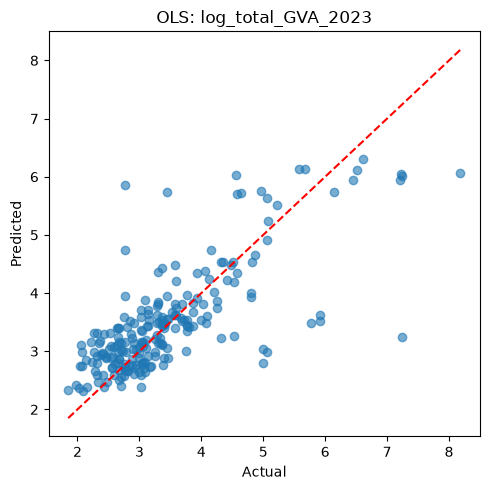

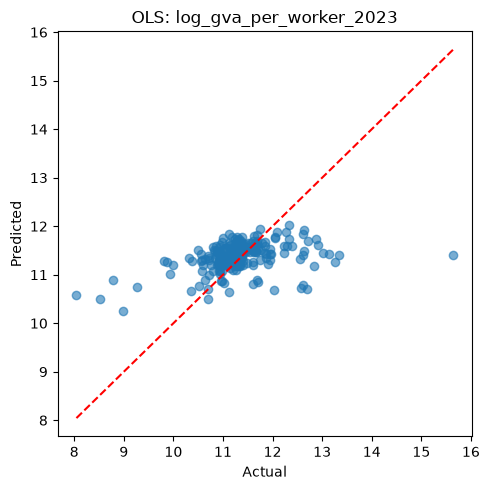

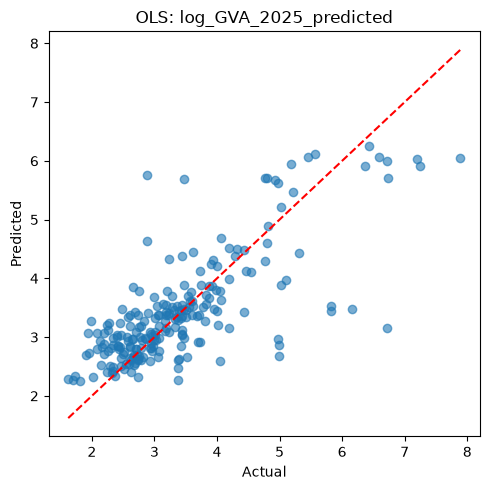

In [18]:
for target in TARGETS:
    model = LinearRegression()
    model.fit(train[FEATURES], train[target])
    y_pred = model.predict(test[FEATURES])
    y_true = test[target]

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"OLS: {target}")
    plt.tight_layout()
    plt.show()

---
## 9.  Swindon portability check

Split test set by `is_swindon` and evaluate each model separately on:
- Swindon LSOAs only
- Other areas only

Does the model generalise to Swindon?

In [10]:
test["is_swindon"].value_counts()

swindon_test = test[test["is_swindon"] == "Swindon"]
other_test = test[test["is_swindon"] == "Others"]

portability = []

for target in TARGETS:
    model = LinearRegression()
    model.fit(train[FEATURES], train[target])

    for group_name, subset in [("Swindon", swindon_test), ("Others", other_test)]:
        y_true = subset[target]
        y_pred = model.predict(subset[FEATURES])
        portability.append({
            "Target": target,
            "Group": group_name,
            "n": len(subset),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAPE (%)": mape(y_true, y_pred),
            "R²": r2_score(y_true, y_pred),
        })

portability_df = pd.DataFrame(portability)
display(portability_df.round(4))

,Target,Group,n,MAE,RMSE,MAPE (%),R²
0,log_total_GVA_2023,Swindon,18,0.3276,0.4060,11.8665,0.7542
1,log_total_GVA_2023,Others,203,0.5049,0.7580,14.6556,0.5345
2,log_gva_per_worker_2023,Swindon,18,0.3917,0.5286,3.2949,0.2045
3,log_gva_per_worker_2023,Others,203,0.4844,0.7252,4.3140,0.1361
4,log_GVA_2025_predicted,Swindon,18,0.3878,0.5174,15.4242,0.6627
5,log_GVA_2025_predicted,Others,203,0.5092,0.7577,15.0241,0.5502


---
## 10. Live vs work robustness

GVA is workplace-based; `emp_rate` is residence-based.  
Optional check: re-run Model 1 excluding LSOAs where `emp_rate > 1` (commuter hubs).  
Compare R² with vs without commuter hubs.

In [15]:
commuter_hubs = train[train["emp_rate"] > 1]
train_nonhub = train[train["emp_rate"] <= 1]
test_nonhub = test[test["emp_rate"] <= 1]
print(len(train_nonhub), len(test_nonhub))
target = "log_total_GVA_2023"

X_train_nh = train_nonhub[FEATURES]
y_train_nh = train_nonhub[target]
X_test_nh = test_nonhub[FEATURES]
y_test_nh = test_nonhub[target]
model_nh = LinearRegression()
model_nh.fit(X_train_nh, y_train_nh)
y_pred_nh = model_nh.predict(X_test_nh)

print("R² (non-hub):", r2_score(y_test_nh, y_pred_nh))


792 199
R² (non-hub): 0.4083797377515228
